In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Đọc file

In [4]:
price = pd.read_csv("/content/drive/MyDrive/DACS_2/data/DATA ĐÃ QUA XỬ LÝ/price_clean.csv")
gpr = pd.read_csv("/content/drive/MyDrive/DACS_2/data/DATA ĐÃ QUA XỬ LÝ/gpr_clean.csv")
exo = pd.read_csv("/content/drive/MyDrive/DACS_2/data/DATA ĐÃ QUA XỬ LÝ/DAY VIETNAM & SINGAPO/exo_selected_features.csv")

Chuẩn hóa Date cho tất cả file

In [5]:
for df_name, df in {
    "price": price,
    "gpr": gpr,
    "exo": exo
}.items():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df.dropna(subset=["Date"], inplace=True)
    df.sort_values("Date", inplace=True)
    df.drop_duplicates(subset=["Date"], keep="first", inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(df_name)
    print("Số dòng:", df.shape[0])
    print("Từ ngày:", df["Date"].min())
    print("Đến ngày:", df["Date"].max())
    print("-" * 40)

price
Số dòng: 4463
Từ ngày: 2008-05-02 00:00:00
Đến ngày: 2026-02-20 00:00:00
----------------------------------------
gpr
Số dòng: 6396
Từ ngày: 2008-05-01 00:00:00
Đến ngày: 2025-11-03 00:00:00
----------------------------------------
exo
Số dòng: 6571
Từ ngày: 2008-01-05 00:00:00
Đến ngày: 2025-12-31 00:00:00
----------------------------------------


Cắt về khoảng thời gian chung

In [6]:
start_date = max(
    price["Date"].min(),
    gpr["Date"].min(),
    exo["Date"].min()
)

end_date = min(
    price["Date"].max(),
    gpr["Date"].max(),
    exo["Date"].max()
)

print("Khoảng thời gian chung:")
print(start_date, "→", end_date)

price_cut = price[
    (price["Date"] >= start_date) &
    (price["Date"] <= end_date)
].copy()

gpr_cut = gpr[
    (gpr["Date"] >= start_date) &
    (gpr["Date"] <= end_date)
].copy()

exo_cut = exo[
    (exo["Date"] >= start_date) &
    (exo["Date"] <= end_date)
].copy()

print("price_cut:", price_cut.shape)
print("gpr_cut:", gpr_cut.shape)
print("exo_cut:", exo_cut.shape)

Khoảng thời gian chung:
2008-05-02 00:00:00 → 2025-11-03 00:00:00
price_cut: (4388, 12)
gpr_cut: (6395, 6)
exo_cut: (6395, 8)


Merge file đầy đủ

In [7]:
merged = (
    price_cut
    .merge(gpr_cut, on="Date", how="left")
    .merge(exo_cut, on="Date", how="left")
)

merged = merged.sort_values("Date").reset_index(drop=True)

print("Kích thước sau merge:", merged.shape)
display(merged.head())
display(merged.tail())

Kích thước sau merge: (4388, 24)


,Date,MG95,MG92,MG97,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,...,GPRD_ACT,GPRD_THREAT,Has_GPR_Event,IsMonthStart,IsMonthEnd,NgayLeSG,NgayLeVN,NgayLe,SuKienDacBiet,GanNgayLe
0,2008-05-02,115.10,114.37,117.71,102.97,137.52,NaN,141.14,559.09,111.895,...,84.521385,30.213936,0,0,0,0,0,0,0,1
1,2008-05-05,120.11,119.39,122.72,106.65,140.58,NaN,144.12,576.81,116.500,...,53.387062,38.168644,0,0,0,0,0,0,0,0
2,2008-05-06,123.69,123.02,126.25,109.30,143.43,NaN,147.23,589.13,119.625,...,89.813446,57.625603,0,0,0,0,0,0,0,0
3,2008-05-07,126.02,125.40,128.54,109.30,144.51,NaN,148.00,593.83,119.525,...,72.434868,109.850594,0,0,0,0,0,0,0,0
4,2008-05-08,126.92,126.30,129.44,109.39,148.79,NaN,151.19,595.44,119.620,...,55.502041,55.553020,0,0,0,0,0,0,0,0


,Date,MG95,MG92,MG97,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,...,GPRD_ACT,GPRD_THREAT,Has_GPR_Event,IsMonthStart,IsMonthEnd,NgayLeSG,NgayLeVN,NgayLe,SuKienDacBiet,GanNgayLe
4383,2025-10-28,82.08,79.26,83.26,61.60,92.16,93.70,91.89,386.49,64.195,...,194.734421,121.820801,0,0,0,0,0,0,0,0
4384,2025-10-29,82.28,79.46,83.46,61.91,89.93,92.15,90.26,376.69,65.370,...,181.365936,151.277100,0,0,0,0,0,0,0,0
4385,2025-10-30,82.62,79.80,83.80,61.96,90.72,92.83,90.86,376.13,65.245,...,105.887657,187.681625,0,0,0,0,0,0,0,0
4386,2025-10-31,81.78,78.96,82.96,62.85,91.51,94.09,92.02,378.04,65.270,...,167.815598,279.949554,0,0,1,0,0,0,0,0
4387,2025-11-03,82.63,79.81,83.81,63.34,92.06,94.24,91.95,379.94,66.015,...,445.436127,153.739746,0,0,0,0,0,0,0,0


Kiểm tra missing sau merge

In [8]:
missing_table = merged.isna().sum().sort_values(ascending=False)

display(missing_table[missing_table > 0])

,0
WTI,130
DO 0.001%,128
BRT DTD,83
BRT KH,83


In [9]:
exo_binary_cols = [
    "IsMonthStart",
    "IsMonthEnd",
    "NgayLeSG",
    "NgayLeVN",
    "NgayLe",
    "SuKienDacBiet",
    "GanNgayLe"
]

exo_binary_cols = [col for col in exo_binary_cols if col in merged.columns]

merged[exo_binary_cols] = merged[exo_binary_cols].fillna(0)

Sau merge mới tạo lag, rolling, return, target
Tạo biến thời gian

In [10]:
merged["Month"] = merged["Date"].dt.month
merged["Quarter"] = merged["Date"].dt.quarter
merged["DayOfWeek"] = merged["Date"].dt.dayofweek

Tạo feature cho MG95

In [11]:
# Lag của MG95
merged["MG95_lag1"] = merged["MG95"].shift(1)
merged["MG95_lag3"] = merged["MG95"].shift(3)
merged["MG95_lag7"] = merged["MG95"].shift(7)

# Return của MG95
merged["MG95_return1"] = merged["MG95"].pct_change(1, fill_method=None)
merged["MG95_return5"] = merged["MG95"].pct_change(5, fill_method=None)

# Rolling dùng dữ liệu quá khứ, tránh leakage
merged["MG95_MA5_lag1"] = merged["MG95"].shift(1).rolling(window=5).mean()
merged["MG95_MA20_lag1"] = merged["MG95"].shift(1).rolling(window=20).mean()
merged["MG95_STD20_lag1"] = merged["MG95"].shift(1).rolling(window=20).std()

Tạo feature cho Brent/WTI

In [12]:
if "BRT KH" in merged.columns:
    merged["BRT_KH_return1"] = merged["BRT KH"].pct_change(1, fill_method=None)

if "BRT DTD" in merged.columns:
    merged["BRT_DTD_return1"] = merged["BRT DTD"].pct_change(1, fill_method=None)

if "WTI" in merged.columns:
    merged["WTI_return1"] = merged["WTI"].pct_change(1, fill_method=None)

Tạo feature cho GPR

In [13]:
if "GPRD" in merged.columns:
    merged["GPRD_lag1"] = merged["GPRD"].shift(1)
    merged["GPRD_lag3"] = merged["GPRD"].shift(3)
    merged["GPRD_lag7"] = merged["GPRD"].shift(7)

    merged["GPRD_MA7_lag1"] = merged["GPRD"].shift(1).rolling(window=7).mean()

### Visualize Return Features

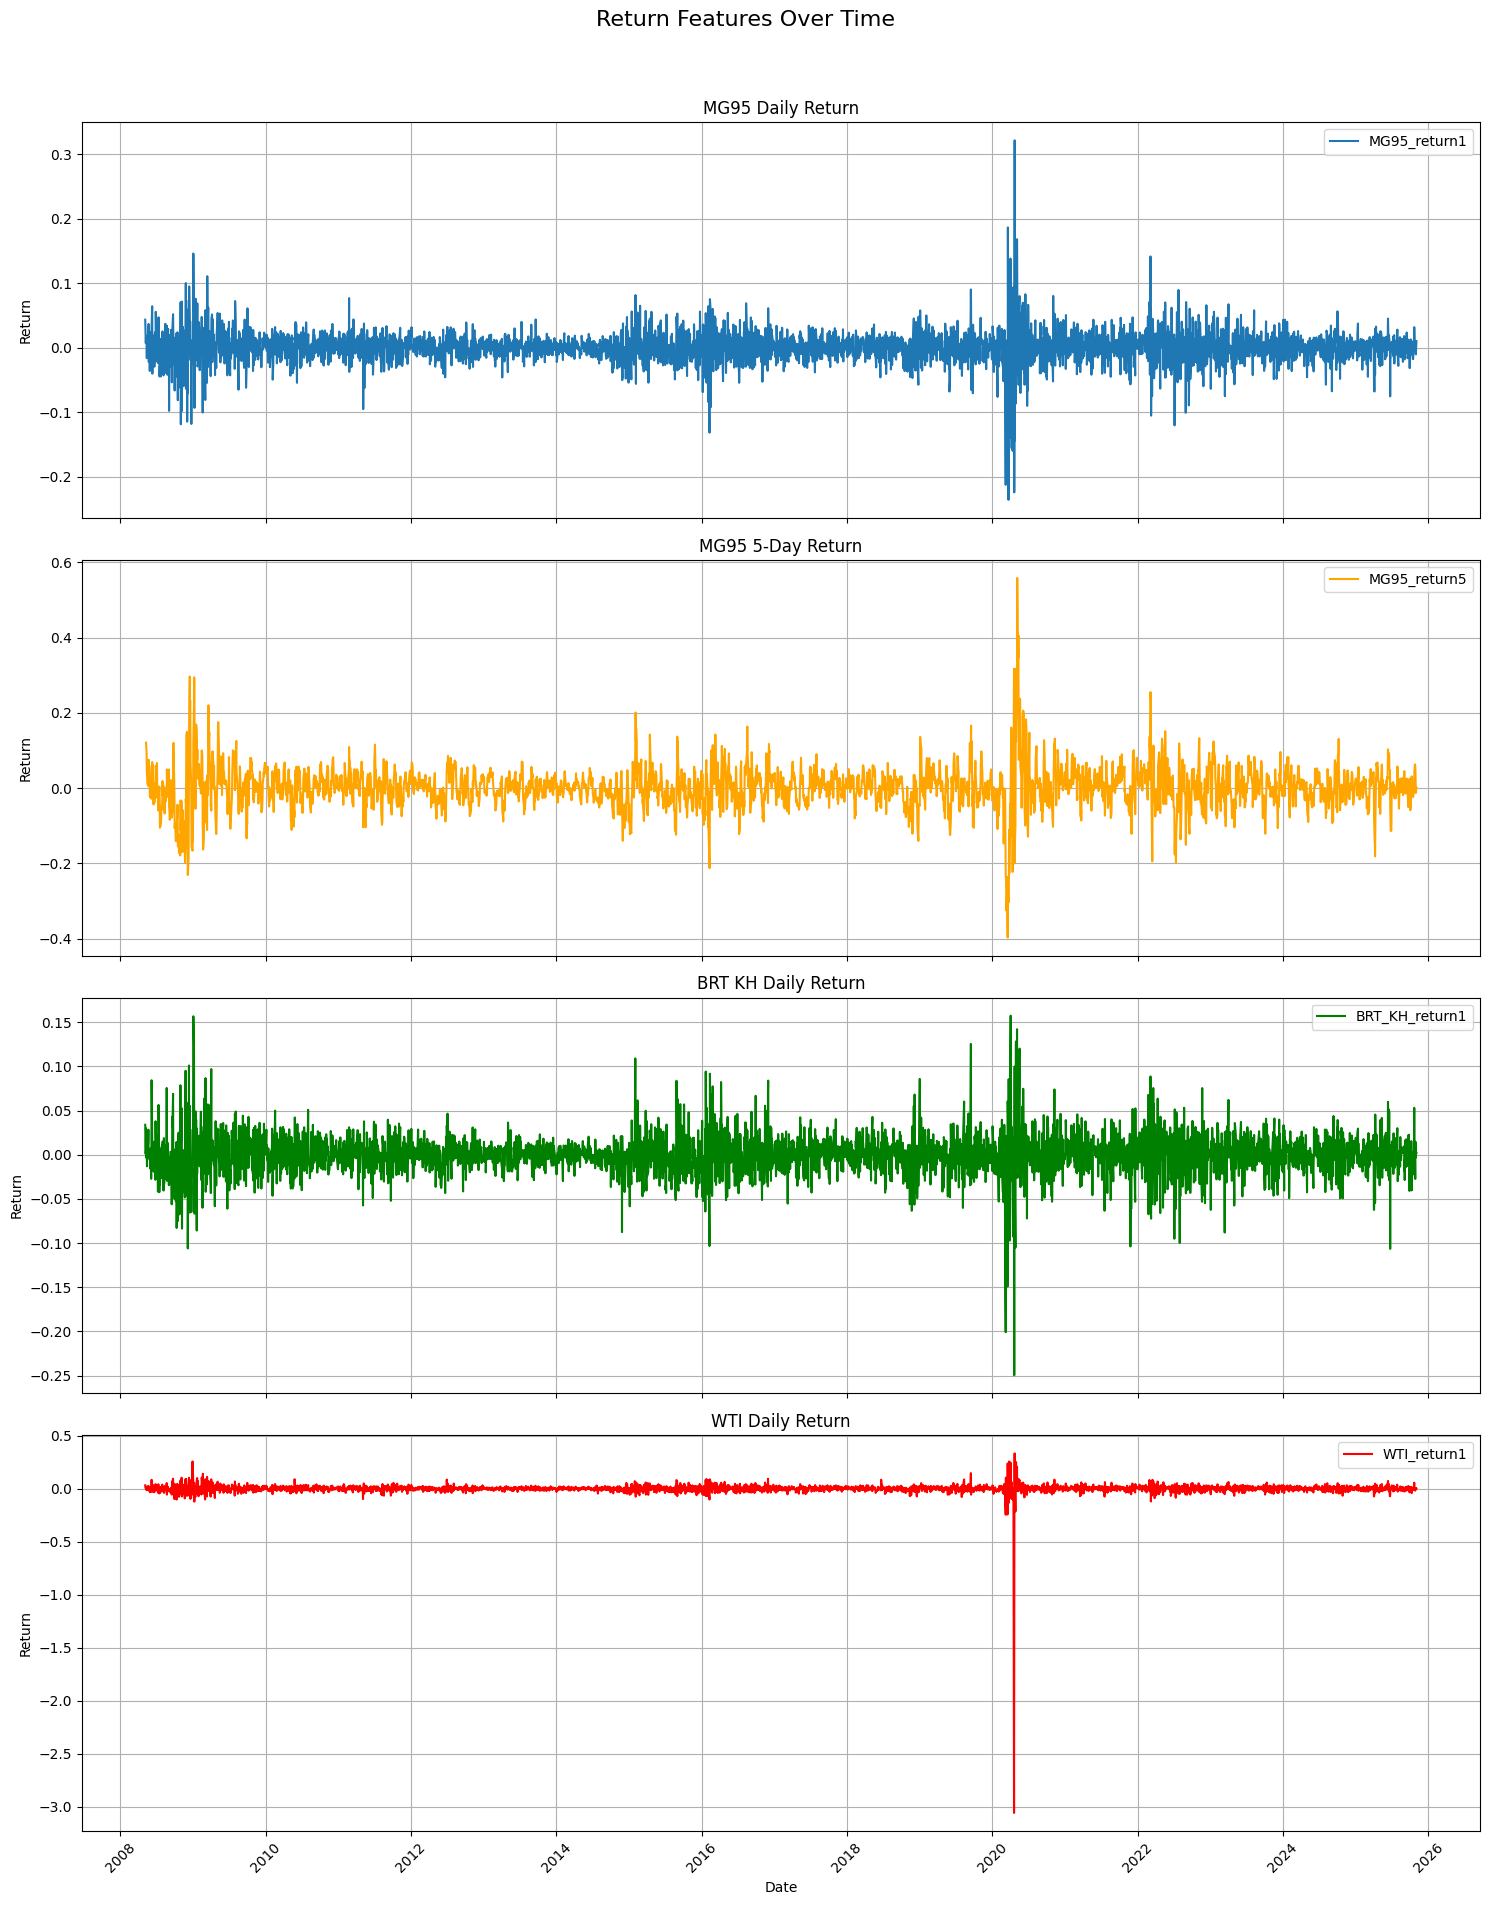

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20), sharex=True)
fig.suptitle('Return Features Over Time', fontsize=16)

# MG95_return1
sns.lineplot(ax=axes[0], x=merged['Date'], y=merged['MG95_return1'], label='MG95_return1')
axes[0].set_title('MG95 Daily Return')
axes[0].set_ylabel('Return')
axes[0].grid(True)

# MG95_return5
sns.lineplot(ax=axes[1], x=merged['Date'], y=merged['MG95_return5'], label='MG95_return5', color='orange')
axes[1].set_title('MG95 5-Day Return')
axes[1].set_ylabel('Return')
axes[1].grid(True)

# BRT_KH_return1
if 'BRT_KH_return1' in merged.columns:
    sns.lineplot(ax=axes[2], x=merged['Date'], y=merged['BRT_KH_return1'], label='BRT_KH_return1', color='green')
    axes[2].set_title('BRT KH Daily Return')
    axes[2].set_ylabel('Return')
    axes[2].grid(True)
else:
    axes[2].set_visible(False) # Hide if column not present

# WTI_return1
if 'WTI_return1' in merged.columns:
    sns.lineplot(ax=axes[3], x=merged['Date'], y=merged['WTI_return1'], label='WTI_return1', color='red')
    axes[3].set_title('WTI Daily Return')
    axes[3].set_ylabel('Return')
    axes[3].grid(True)
else:
    axes[3].set_visible(False) # Hide if column not present


plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

Tạo target t+1, t+3, t+7

In [15]:
merged["MG95_t_+_1"] = merged["MG95"].shift(-1)
merged["MG95_t_+_3"] = merged["MG95"].shift(-3)
merged["MG95_t_+_7"] = merged["MG95"].shift(-7)

dataset model

In [16]:
feature_cols = [
    "MG95_lag1",
    "MG95_lag3",
    "MG95_lag7",
    "MG95_return1",
    "MG95_return5",
    "MG95_MA5_lag1",
    "MG95_STD20_lag1",

    "BRT_KH_return1",
    "WTI_return1",

    "GPRD_lag1",
    "GPRD_lag3",
    "GPRD_lag7",
    "GPRD_MA7_lag1",

    "Has_GPR_Event",

    "NgayLe",
    "GanNgayLe",
    "SuKienDacBiet",
    "IsMonthStart",
    "IsMonthEnd",

    "Month",
    "Quarter",
    "DayOfWeek"
]

feature_cols = [col for col in feature_cols if col in merged.columns]

Lưu File

In [17]:
merged.to_csv(
    "merged_full_after_feature_engineering.csv",
    index=False,
    encoding="utf-8-sig"
)


# Create model datasets
model_t1 = merged[feature_cols + ["MG95_t_+_1"]].dropna()
model_t3 = merged[feature_cols + ["MG95_t_+_3"]].dropna()
model_t7 = merged[feature_cols + ["MG95_t_+_7"]].dropna()

model_t1.to_csv(
    "model_dataset_MG95_t_+_1.csv",
    index=False,
    encoding="utf-8-sig"
)

model_t3.to_csv(
    "model_dataset_MG95_t_+_3.csv",
    index=False,
    encoding="utf-8-sig"
)

model_t7.to_csv(
    "model_dataset_MG95_t_+_7.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu các file model.")

Đã lưu các file model.


### Visualize Feature Correlation Matrix

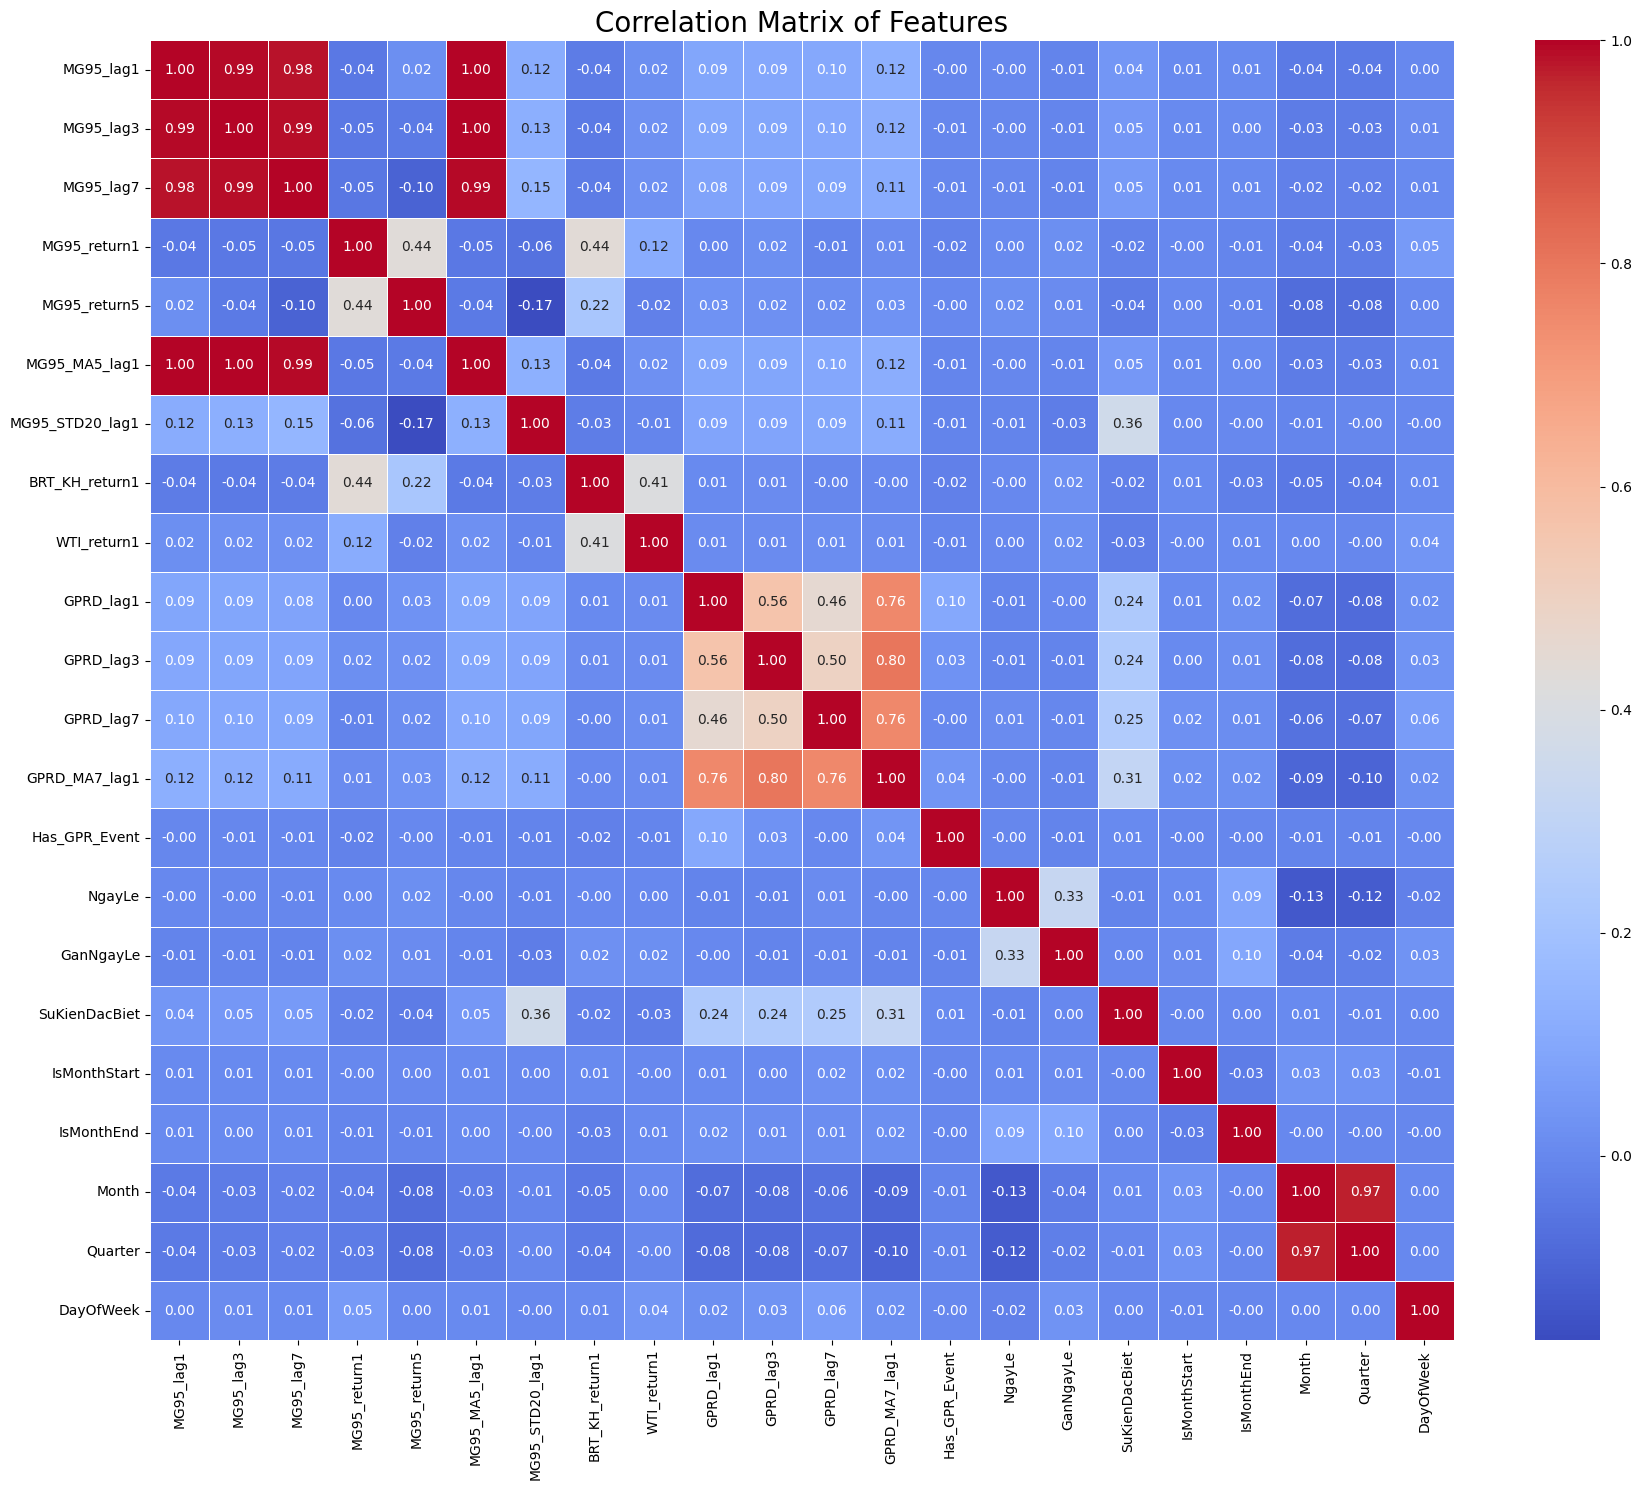

In [19]:
plt.figure(figsize=(18, 15))
corr_matrix = merged[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlation of MG95 with other Features

/tmp/ipykernel_22130/4104259556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mg95_correlations.values, y=mg95_correlations.index, palette='coolwarm')


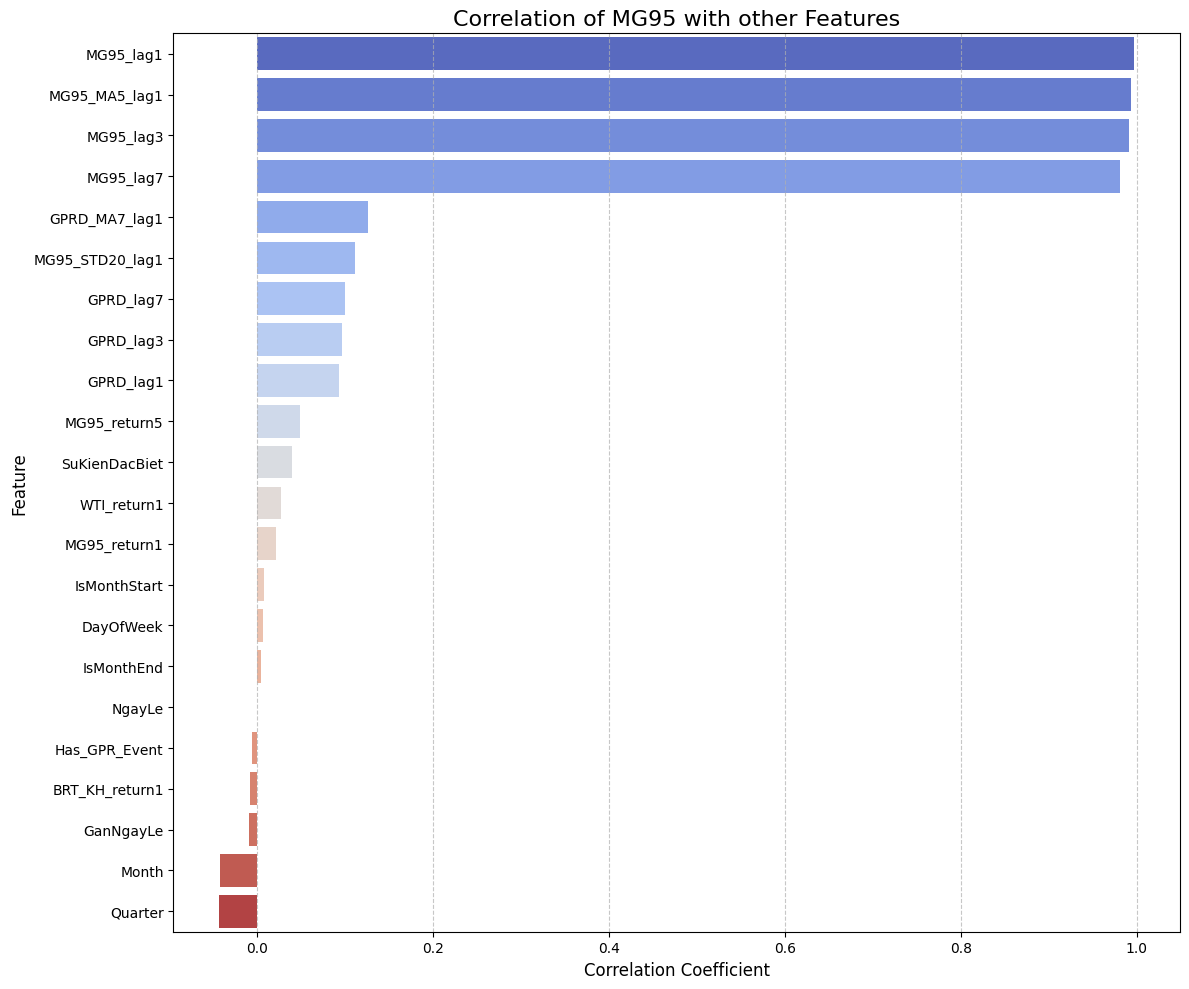

In [20]:
if 'MG95' in merged.columns:
    # Calculate correlation of MG95 with all other feature_cols
    mg95_correlations = merged[feature_cols + ['MG95']].corr()['MG95'].drop('MG95').sort_values(ascending=False)

    plt.figure(figsize=(12, 10))
    sns.barplot(x=mg95_correlations.values, y=mg95_correlations.index, palette='coolwarm')
    plt.title('Correlation of MG95 with other Features', fontsize=16)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("The 'MG95' column is not found in the merged DataFrame.")